# Data Center Facilities & Outcomes Dataset

Generates the canonical facilities/outcomes dataset from the hand-maintained master spreadsheet, excluding tombstoned/retired records. Run against the real master spreadsheet.

### Docstring, imports, and config

In [1]:
"""
build_facilities_outcomes.py

Generates facilities_outcomes.csv FROM Complete_dc_outcomes.xlsx.

WORKFLOW (2026-07-30 onward): Complete_dc_outcomes.xlsx is the single
source of truth (renamed from Complete_dc_outcomes_MERGED.xlsx -- that name
is retired). Make ALL edits, additions, and corrections there. Never hand
-edit facilities_outcomes.csv directly -- it is a generated artifact and will
be silently overwritten the next time this script runs. Re-run this script any
time the xlsx changes to refresh facilities_outcomes.csv.

Usage:
    python build_facilities_outcomes.py

Excludes tombstoned rows (Facility_Name starting with "TOMBSTONE" or
"[TOMBSTONE", or DC_Status containing "tombstone") -- these stay in the xlsx
master for audit history but are not carried into facilities_outcomes.csv.

COLUMN MAPPING (facilities_outcomes.csv column <- xlsx source):
  Straight copies (same name, same meaning, xlsx is authoritative):
    Facility_number, Facility_Name, DC_Status, State, County, Street_Address,
    Zip, Date_Announced, Date_Proposed, Date_Approved, Date_Denied_Withdrawn,
    Date_Construction_Began, Date_Operational, Latitude, Longitude,
    Hyperscaler, Known_Aliases, expected_approval_body, incorporation_status,
    county_geoid_geocoded, place_geoid_geocoded, place_name_geocoded,
    Direct_Opposition_Merged, Opposition_Summary, Opposition_Before_Approval,
    Opposition_Reasons, Status_Normalized,
    dc_application_filed_date, dc_rezoning_approved_date,
    dc_site_plan_approved_date, dc_operational_date_proposed
    (the last 8 columns were migrated into the xlsx on 2026-07-30 specifically
    so it could become the sole source -- they did not previously exist there)

  CLEAN-COLUMN substitutions (messy xlsx field -> clean xlsx field used instead):
    Municipality <- Municipality_Clean (NOT the raw, narrative-heavy
      Municipality column, which carries correction notes, parentheticals,
      and background context not needed in the clean extract)

  DERIVED (computed from xlsx's split-scheme columns, since the old conflated
  scheme has no direct column in xlsx anymore after the 2026-07-30 rename):
    Site_Type_Normalized <- derived from xlsx's Industrial_Zoned + Site_Type
      via the established conflation rule: Industrial_Zoned=='Yes' ->
      'Industrial'; else Greenfield/Greenfield-Agricultural -> 'Greenfield',
      Brownfield -> 'Brownfield', Greyfield -> 'Adaptive-reuse'
    Build_Type_Normalized <- xlsx's Build_Type (direct copy; values already
      match, 'New'/'Converted')
    jurisdiction_municipal <- derived from xlsx's zoning_jurisdiction
      ('Municipal' -> 1, 'County' -> 0, else blank)

  NOT migrated (dropped from facilities_outcomes.csv's schema):
    Unnamed: 0 -- was just a row-sequence artifact from the original CSV
    export; regenerated fresh as a simple 0..N index, not sourced from xlsx.
"""
import csv
import openpyxl

### Column mapping and exclusion rules

In [2]:
XLSX_PATH = 'Complete_dc_outcomes.xlsx'
OUTPUT_PATH = 'facilities_outcomes.csv'

OUTPUT_COLUMNS = [
    'Unnamed: 0', 'Facility_number', 'Facility_Name', 'DC_Status', 'State', 'County',
    'Street_Address', 'Zip', 'Municipality', 'Date_Announced', 'Date_Proposed',
    'dc_application_filed_date', 'dc_rezoning_approved_date', 'dc_site_plan_approved_date',
    'Date_Approved', 'Date_Denied_Withdrawn', 'Date_Construction_Began', 'Date_Operational',
    'dc_operational_date_proposed', 'Latitude', 'Longitude', 'Hyperscaler', 'Known_Aliases',
    'jurisdiction_municipal', 'expected_approval_body', 'incorporation_status',
    'county_geoid_geocoded', 'place_geoid_geocoded', 'place_name_geocoded',
    'Direct_Opposition_Merged', 'Opposition_Summary', 'Opposition_Before_Approval',
    'Opposition_Reasons', 'Status_Normalized', 'Site_Type_Normalized', 'Build_Type_Normalized',
]

# Straight copies: output column name -> xlsx source column name (same name)
STRAIGHT_COPY = [
    'Facility_number', 'Facility_Name', 'DC_Status', 'State', 'County', 'Street_Address', 'Zip',
    'Date_Announced', 'Date_Proposed', 'dc_application_filed_date', 'dc_rezoning_approved_date',
    'dc_site_plan_approved_date', 'Date_Approved', 'Date_Denied_Withdrawn',
    'Date_Construction_Began', 'Date_Operational', 'dc_operational_date_proposed',
    'Latitude', 'Longitude', 'Hyperscaler', 'Known_Aliases', 'expected_approval_body',
    'incorporation_status', 'county_geoid_geocoded', 'place_geoid_geocoded',
    'place_name_geocoded', 'Direct_Opposition_Merged', 'Opposition_Summary',
    'Opposition_Before_Approval', 'Opposition_Reasons', 'Status_Normalized',
]

### Helper functions (tombstone detection, site-type mapping)

In [3]:
def is_tombstone(facility_name, dc_status):
    name = (facility_name or '').strip().upper()
    status = (dc_status or '')
    return name.startswith('TOMBSTONE') or name.startswith('[TOMBSTONE') or 'tombstone' in status.lower()


def old_site_type(industrial_zoned, site_type):
    """Conflate the split scheme (Site_Type + Industrial_Zoned) into the
    older single-field taxonomy facilities_outcomes.csv has always used."""
    if industrial_zoned == 'Yes':
        return 'Industrial'
    mapping = {
        'Greenfield': 'Greenfield',
        'Greenfield-Agricultural': 'Greenfield',
        'Brownfield': 'Brownfield',
        'Greyfield': 'Adaptive-reuse',
    }
    return mapping.get(site_type, 'Unknown')

### Main pipeline: load, map, filter, save

In [4]:
def main():
    wb = openpyxl.load_workbook(XLSX_PATH, read_only=True, data_only=True)
    ws = wb['Complete_dc_outcomes']
    headers = [c.value for c in next(ws.iter_rows(min_row=1, max_row=1))]
    idx = {h: i for i, h in enumerate(headers)}

    out_rows = []
    row_num = 0
    skipped_tombstones = 0
    for row in ws.iter_rows(min_row=2, values_only=True):
        name = row[idx['Facility_Name']]
        status = row[idx['DC_Status']]
        if is_tombstone(name, status):
            skipped_tombstones += 1
            continue

        out = {}
        out['Unnamed: 0'] = row_num
        row_num += 1

        for col in STRAIGHT_COPY:
            out[col] = row[idx[col]] if col in idx else ''

        out['Municipality'] = row[idx['Municipality_Clean']] if 'Municipality_Clean' in idx else row[idx['Municipality']]

        zj = row[idx['zoning_jurisdiction']] if 'zoning_jurisdiction' in idx else None
        out['jurisdiction_municipal'] = 1 if zj == 'Municipal' else (0 if zj == 'County' else '')

        industrial_zoned = row[idx['Industrial_Zoned']] if 'Industrial_Zoned' in idx else ''
        site_type = row[idx['Site_Type']] if 'Site_Type' in idx else ''
        out['Site_Type_Normalized'] = old_site_type(industrial_zoned, site_type)
        out['Build_Type_Normalized'] = row[idx['Build_Type']] if 'Build_Type' in idx else ''

        out_rows.append(out)

    with open(OUTPUT_PATH, 'w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=OUTPUT_COLUMNS)
        writer.writeheader()
        writer.writerows(out_rows)

    print(f"Wrote {len(out_rows)} rows to {OUTPUT_PATH} (skipped {skipped_tombstones} tombstoned rows)")


if __name__ == '__main__':
    main()

Wrote 1228 rows to facilities_outcomes.csv (skipped 280 tombstoned rows)


## Visualization

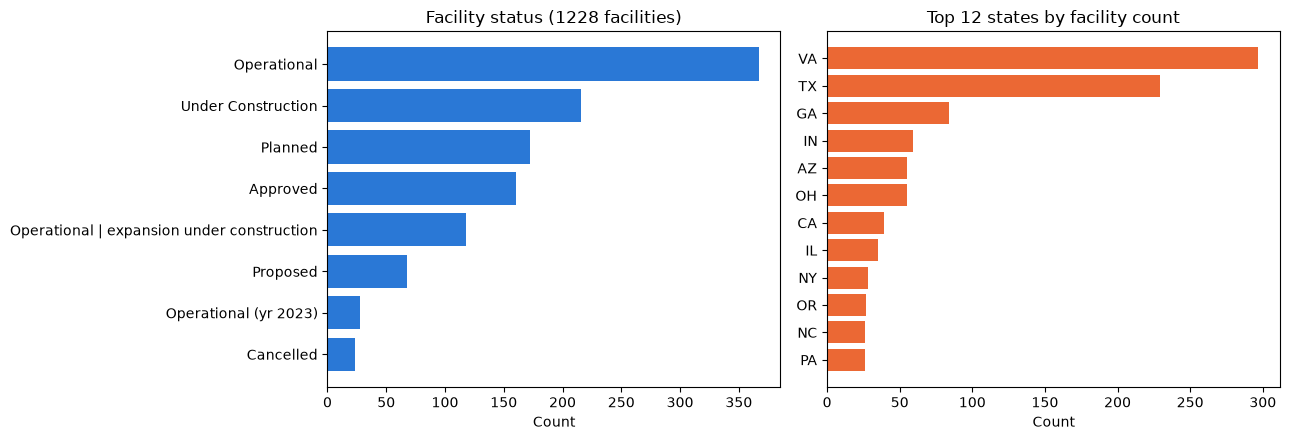

Share of facilities with confirmed direct opposition: 26.1%


In [5]:

import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10



import pandas as pd
df = pd.read_csv("facilities_outcomes.csv", low_memory=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

status_counts = df["Status_Normalized"].value_counts().head(8)
axes[0].barh(status_counts.index, status_counts.values, color="#2a78d6")
axes[0].invert_yaxis()
axes[0].set_title(f"Facility status ({len(df)} facilities)")
axes[0].set_xlabel("Count")

top_states = df["State"].value_counts().head(12)
axes[1].barh(top_states.index, top_states.values, color="#eb6834")
axes[1].invert_yaxis()
axes[1].set_title("Top 12 states by facility count")
axes[1].set_xlabel("Count")

plt.tight_layout()
plt.show()

if "Direct_Opposition_Merged" in df:
    opp_rate = df["Direct_Opposition_Merged"].astype(str).str.upper().str.startswith("YES").mean()
    print(f"Share of facilities with confirmed direct opposition: {opp_rate:.1%}")
